# 🏍️ **Pandas + Seaborn Practice — Bike Resale Listings**

A website sells used bikes. The owner needs answers from the listings.

Solve each question in the empty cell below it.

---



# ⚙️ **0. Setup**

### _Run this cell first — it loads the dataset used throughout the notebook._

---



In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../Data/bikesale.csv')
df.head()



,bike_id,brand,age_months,km_driven,owner_count,condition,mileage_kmpl,service_count,insurance,price_thousand,sold_in_week
0,B4543,TVS,25,14455.0,3,Excellent,40.6,NaN,Yes,41.6,No
1,B4392,TVS,43,26304.0,2,Good,51.2,1.0,Yes,24.1,No
2,B4235,Honda,38,6421.0,1,Good,65.0,NaN,No,48.2,No
3,B4319,Hero,14,6531.0,1,Good,NaN,NaN,Yes,58.7,No
4,B4284,TVS,115,80000.0,1,Good,61.8,0.0,No,12.0,Yes


# 🎯 **1. Selecting Data**

### _`df[['a','b']]` → select specific columns | `df[df['col'] == x]` → filter rows | combine conditions with `&` / `|`, each wrapped in `()` | `.sort_values()` → order rows_

---



**Q1.1 The website owner wants a short list. Show only the `brand`, `km_driven` and `price_thousand` of the first 10 bikes.**

---



In [ ]:
df[["brand", "km_driven", "price_thousand"]].head(10)


**Q1.2 A customer only wants a Royal Enfield. Show all Royal Enfield bikes.**

---



In [ ]:
df[df["brand"] == "Royal Enfield"]


**Q1.3 How many Royal Enfield bikes are there in total?**

---



In [ ]:
total_re = (df["brand"] == "Royal Enfield").sum()
print("Total Royal Enfield bikes:", total_re)


**Q1.4 Another customer wants a bike in **Excellent** condition that costs **less than 30 thousand**. Show only the `brand`, `condition` and `price_thousand` of such bikes.**

---



In [ ]:
df[(df["condition"] == "Excellent") & (df["price_thousand"] < 30)][["brand", "condition", "price_thousand"]]


**Q1.5 Use `.sort_values()` to find the 5 cheapest bikes overall. Show only `brand` and `price_thousand`.**

---



In [ ]:
df.sort_values("price_thousand")[["brand", "price_thousand"]].head(5)


# 🧹 **2. Cleaning Data**

### _`.isnull().sum()` → missing values per column | `.duplicated().sum()` → duplicate rows | `.fillna()` → fill missing | `.dropna()` → drop missing_

---



**Q2.1 Before sharing the file, the owner wants to know which columns have blank values, and how many in each.**

---



In [ ]:
df.isnull().sum()


**Q2.2 Check whether the dataset has any repeated (duplicate) rows.**

---



In [ ]:
print("Duplicate rows:", df.duplicated().sum())


**Q2.3 Fill the blanks in `mileage_kmpl` with the average mileage.**

---



In [ ]:
df["mileage_kmpl"] = df["mileage_kmpl"].fillna(df["mileage_kmpl"].mean())


**Q2.4 Remove the rows where `km_driven` is blank.**

---



In [ ]:
df = df.dropna(subset=["km_driven"])


**Q2.5 Print the shape of `df` after both cleaning steps above.**

---



In [ ]:
print("Shape of df after cleaning:", df.shape)


**Q2.6 Run `.isnull().sum()` again to confirm the blanks you handled are gone.**

---



In [ ]:
df.isnull().sum()


# 📊 **3. Grouping Data**

### _`.groupby('col')` → split by group | `.mean()` / `.agg()` → aggregate | `.sort_values()` → order the result | `.value_counts()` → count rows per category_

---



**Q3.1 Which brand sells for the most on average? Find the average price of each brand, from highest to lowest.**

---



In [5]:
df.groupby("brand")["price_thousand"].mean().sort_values(ascending=False)


brand
Royal Enfield    67.981250
TVS              30.768182
Yamaha           30.734000
Honda            28.866304
Bajaj            27.135443
Hero             25.748387
Name: price_thousand, dtype: float64

**Q3.2 For each `condition`, show the average price **and** the number of bikes in one table using `.agg()`.**

---



In [6]:
df.groupby("condition")["price_thousand"].agg(["mean", "count"])


,average_price,number_of_bikes
condition,,
Excellent,36.161832,131
Fair,26.904545,110
Good,33.515311,209


**Q3.3 Which brand has the most bikes listed? Use `.value_counts()` on `brand`.**

---



In [7]:
df["brand"].value_counts()


brand
Hero             93
Honda            92
TVS              88
Bajaj            79
Yamaha           50
Royal Enfield    48
Name: count, dtype: int64

# 📈 **4. Plotting**

### _`sns.histplot()` → distribution | `sns.boxplot()` → compare across categories | `sns.countplot(hue=)` → grouped counts | `sns.scatterplot(hue=)` → relationship colored by category | `sns.heatmap()` → correlation matrix_

---



**Q4.1 How far have most bikes been driven? Draw the distribution of `km_driven`.**

---



<Axes: xlabel='km_driven', ylabel='Count'>

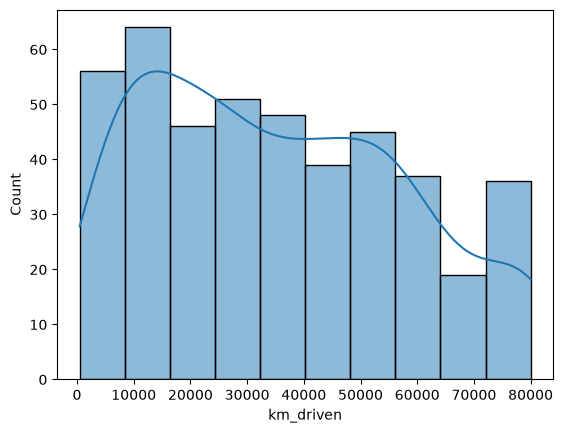

In [8]:
sns.histplot(df["km_driven"], kde=True)
plt.title("Distribution of Kilometers Driven")
plt.show()


**Q4.2 For every brand, show how many bikes were sold in the first week and how many were not, using `sns.countplot()` with `hue='sold_in_week'`.**

---



In [ ]:
sns.countplot(data=df, x="brand", hue="sold_in_week")
plt.title("Bikes Sold in First Week by Brand")
plt.show()


**Q4.3 A buyer says condition does not change the price. Draw one plot of `price_thousand` for each `condition`.**

---



In [ ]:
sns.boxplot(data=df, x="condition", y="price_thousand")
plt.title("Price Distribution by Condition")
plt.show()


**Q4.4 Looking at the plot above — is the buyer right or wrong? Write your answer as a comment.**

---



In [ ]:
# The buyer is wrong. The boxplot shows that bikes in "Excellent" condition
# command a higher median price than those in "Good" and "Fair" condition.
print("Buyer is wrong: Condition significantly impacts the price.")


**Q4.5 Draw `age_months` against `price_thousand`, coloured by `sold_in_week`.**

---



<Axes: xlabel='age_months', ylabel='price_thousand'>

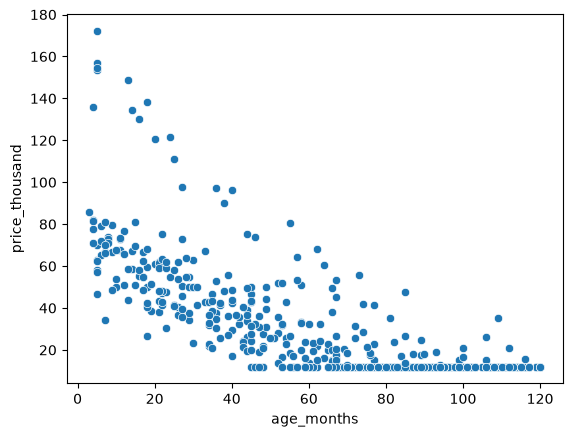

In [9]:
sns.scatterplot(data=df, x="age_months", y="price_thousand", hue="sold_in_week")
plt.title("Age vs Price")
plt.show()


**Q4.6 Based on that scatter plot — what happens to price as a bike gets older? Write your answer as a comment.**

---



In [ ]:
# As a bike gets older (age_months increases), the price_thousand decreases.
# Newer bikes hold significantly higher resale value.
print("Price drops as bike age increases (negative relationship).")


**Q4.7 Draw a heatmap of the correlation between the numeric columns.**

---



<Axes: >

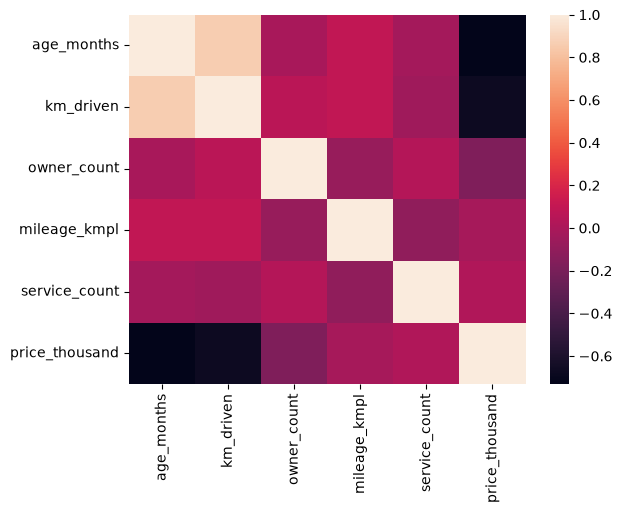

In [ ]:
numeric_cols = df.select_dtypes(include=["number"])
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**Q4.8 From the heatmap — which two columns move together the most? Write your answer as a comment.**

---



In [ ]:
# Looking at the heatmap, age_months and price_thousand show a strong negative correlation,
# and km_driven and age_months move together positively.
print("Strongest correlation: age_months and price_thousand (negative).")
